# ANALYSIS OF RADIATION USING DATA FROM CERES EBAF-TOA

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.open_dataset('CERES_EBAF-TOA_Ed4.2.1_Subset_202401-202501.nc')

# A. Radiasi Matahari di Kota Bandung

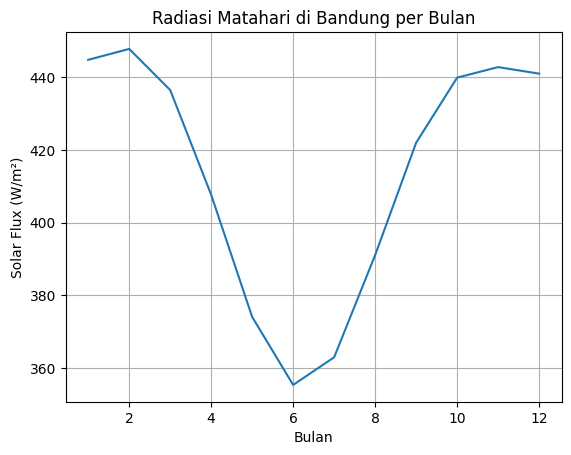

In [2]:
#koordinat Bandung
lat_bdg, lon_bdg = -6.9, 107.6
lat_idx = abs(ds.lat - lat_bdg).argmin()
lon_idx = abs(ds.lon - lon_bdg).argmin()

bulan = range(1, 13)
solar_bandung = ds['solar_mon'][:12, lat_idx, lon_idx]
plt.plot(bulan, solar_bandung)
plt.title("Radiasi Matahari di Bandung per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Solar Flux (W/m²)")
plt.grid()
plt.show()



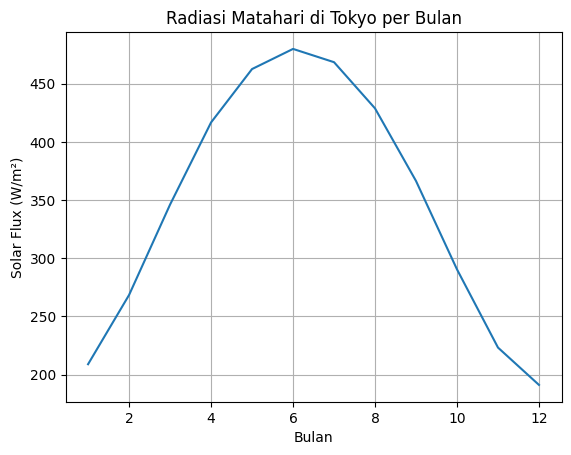

In [4]:
# Temukan indeks terdekat koordinat Tokyo
lat_tky, lon_tky = 35.6, 139.7
lat_jpx = abs(ds.lat - lat_tky).argmin()
lon_jpx = abs(ds.lon - lon_tky).argmin()

bulan = range(1, 13)
solar_bandung = ds['solar_mon'][:12, lat_jpx, lon_jpx]
plt.plot(bulan, solar_bandung)
plt.title("Radiasi Matahari di Tokyo per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Solar Flux (W/m²)")
plt.grid()
plt.show()



# B. Radiasi Keluar Bumi di Bandung

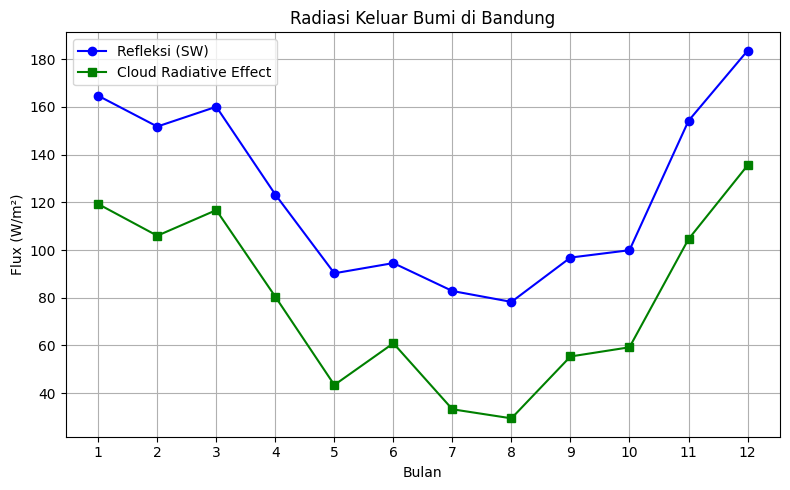

In [5]:
# Ambil hanya 12 bulan pertama
sw_all = ds['toa_sw_all_mon'][:12, lat_idx, lon_idx]
lw_all = ds['toa_lw_all_mon'][:12, lat_idx, lon_idx]
sw_clr = ds['toa_sw_clr_c_mon'][:12, lat_idx, lon_idx]

# Hitung SW CRE
sw_cre = sw_all - sw_clr

# Buat sumbu x untuk 12 bulan
bulan = range(1, 13)

# Plot data
plt.figure(figsize=(8, 5))
plt.plot(bulan, sw_all, marker='o', label='Refleksi (SW)', color='blue')
plt.plot(bulan, sw_cre, marker='s', label="Cloud Radiative Effect", color='green')
plt.title("Radiasi Keluar Bumi di Bandung")
plt.xlabel("Bulan")
plt.ylabel("Flux (W/m²)")
plt.legend()
plt.grid(True)
plt.xticks(bulan)
plt.tight_layout()
plt.show()

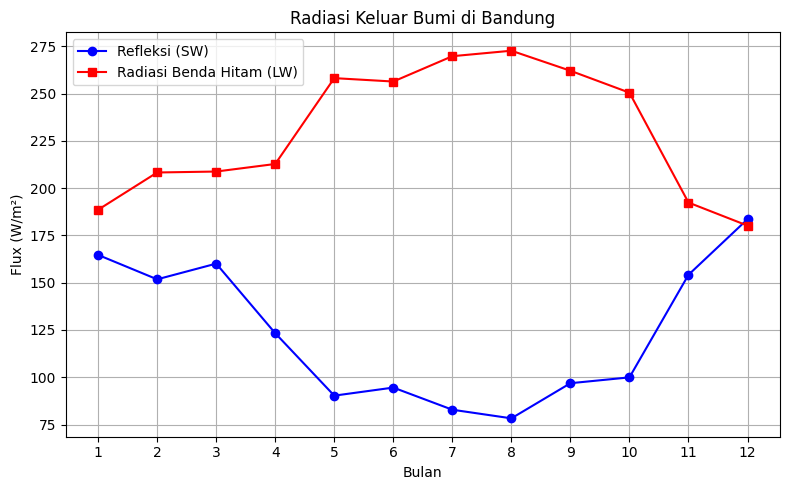

In [6]:
# Ambil hanya 12 bulan pertama
sw_all = ds['toa_sw_all_mon'][:12, lat_idx, lon_idx]
lw_all = ds['toa_lw_all_mon'][:12, lat_idx, lon_idx]

# Buat sumbu x untuk 12 bulan
bulan = range(1, 13)

# Plot data
plt.figure(figsize=(8, 5))
plt.plot(bulan, sw_all, marker='o', label='Refleksi (SW)', color='blue')
plt.plot(bulan, lw_all, marker='s', label='Radiasi Benda Hitam (LW)', color='red')
plt.title("Radiasi Keluar Bumi di Bandung")
plt.xlabel("Bulan")
plt.ylabel("Flux (W/m²)")
plt.legend()
plt.grid(True)
plt.xticks(bulan)
plt.tight_layout()
plt.show()


# C. Radiasi Keluar Bumi di Tokyo

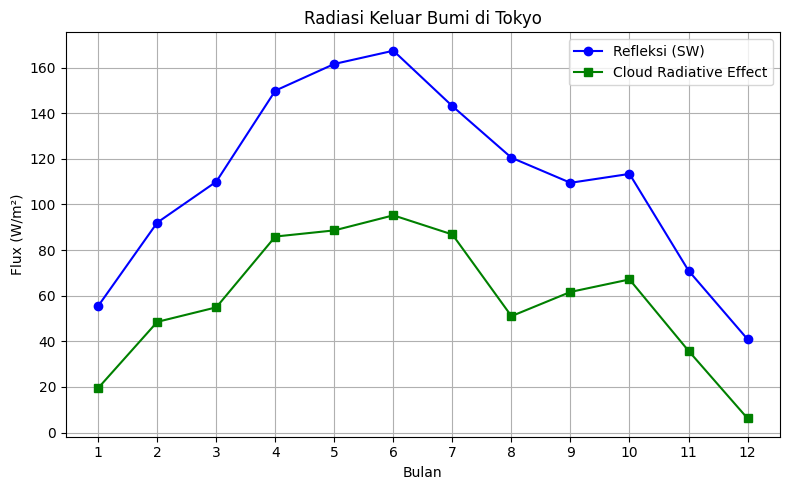

In [7]:
# Ambil hanya 12 bulan pertama
sw_all = ds['toa_sw_all_mon'][:12, lat_jpx, lon_jpx]
lw_all = ds['toa_lw_all_mon'][:12, lat_jpx, lon_jpx]
sw_clr = ds['toa_sw_clr_c_mon'][:12, lat_jpx, lon_jpx]

# Hitung SW CRE
sw_cre = sw_all - sw_clr
bulan = range(1, 13)

# Plot data
plt.figure(figsize=(8, 5))
plt.plot(bulan, sw_all, marker='o', label='Refleksi (SW)', color='blue')
plt.plot(bulan, sw_cre, marker='s', label="Cloud Radiative Effect", color='green')
plt.title("Radiasi Keluar Bumi di Tokyo")
plt.xlabel("Bulan")
plt.ylabel("Flux (W/m²)")
plt.legend()
plt.grid(True)
plt.xticks(bulan)
plt.tight_layout()
plt.show()


# D. Pemanasan Global di Kota Bandung

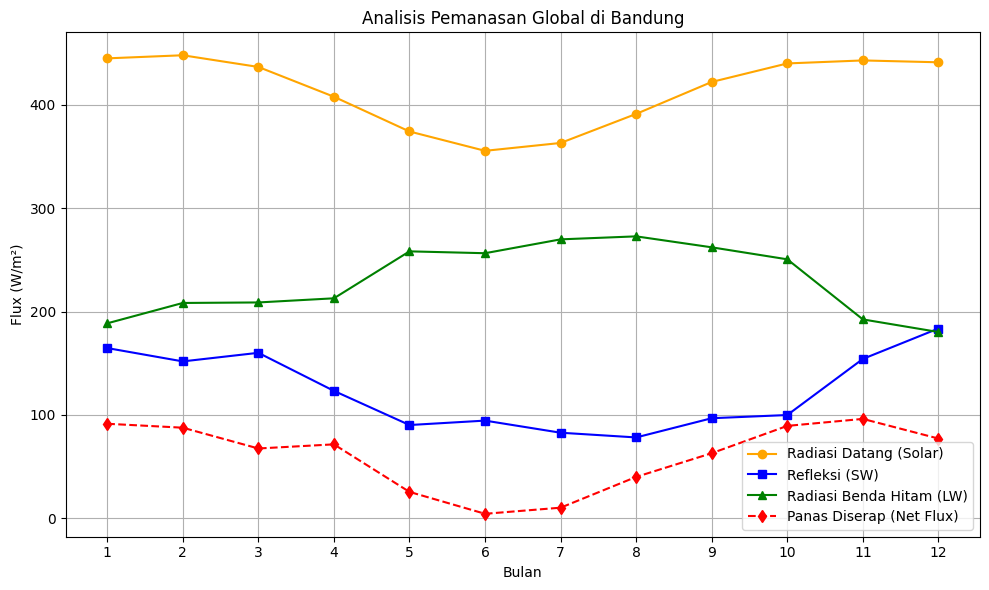

Daya total yang diserap bumi di Bandung selama 1 tahun: 724.84 W/m²


In [8]:
# Ambil data 12 bulan pertama di lokasi Bandung
solar_in = ds['solar_mon'][:12, lat_idx, lon_idx]
sw_out = ds['toa_sw_all_mon'][:12, lat_idx, lon_idx]
lw_out = ds['toa_lw_all_mon'][:12, lat_idx, lon_idx]

# Hitung total radiasi keluar
total_out = sw_out + lw_out

# Hitung radiasi bersih (diserap oleh bumi)
net_flux = solar_in - total_out

# Plot ketiga komponen
bulan = range(1, 13)
plt.figure(figsize=(10, 6))
plt.plot(bulan, solar_in, marker='o', label='Radiasi Datang (Solar)', color='orange')
plt.plot(bulan, sw_out, marker='s', label='Refleksi (SW)', color='blue')
plt.plot(bulan, lw_out, marker='^', label='Radiasi Benda Hitam (LW)', color='green')
plt.plot(bulan, net_flux, marker='d', label='Panas Diserap (Net Flux)', color='red', linestyle='--')
plt.title("Analisis Pemanasan Global di Bandung")
plt.xlabel("Bulan")
plt.ylabel("Flux (W/m²)")
plt.legend()
plt.grid(True)
plt.xticks(bulan)
plt.tight_layout()
plt.show()

# Hitung daya total diserap selama 1 tahun (dalam W/m²)
net_flux_total = net_flux.sum().item()

print(f"Daya total yang diserap bumi di Bandung selama 1 tahun: {net_flux_total:.2f} W/m²")
